<a href="https://colab.research.google.com/github/Matthew6162/Small-Quant-Finance-Projects/blob/main/Ornstein_Uhlenbeck_Process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Dependencies

In [88]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Defining Variables

$T$: Time horizon

$n$: Number of time steps (e.g. $n$ = 252 days)

$\Delta t$: Time step ($\Delta t = \frac{T}{n}$)

$S_0$: Asset price at time 0 (initial asset price)

$\theta$: Long term mean level

$\sigma$: Volatility

$\kappa$: Mean reversion speed (higher $\implies$ faster)

$\epsilon_i$: Independent standard normal variable, $\epsilon_i \sim \mathbf{N}(0,1)$

In [89]:
num_paths = 100
n = 252
T = 1
dt = T/n
S0 = 1
theta = 1
sigma = 0.2
kappa = 3
S = np.insert(np.zeros((n,num_paths)),0,S0,axis=0)
epsilon = np.random.normal(0,1,(n,num_paths))

# Simulating Standard Ornstein-Uhlenbeck Paths

**Standard Ornstein-Uhlenbeck Process:**

$$dS_t = \kappa(\theta-S_t) dt + \sigma dW_t$$

**Euler-Maruyama Discretization (For simulation):**

$$S_{t+1,j} = S_{t,j} + \kappa(\theta - S_{t,j})\Delta t + \sigma \sqrt{\Delta t}\epsilon_{t,j}$$

where $t \in [0,n-1]$ and $j \in [1,\text{num_paths}]$

In [90]:
for i in range(0,n):
  S[i+1] = S[i] + kappa * (theta - S[i]) * dt + sigma * np.sqrt(dt) * epsilon[i]

# Plotting Standard Ornstein-Uhlenbeck Process

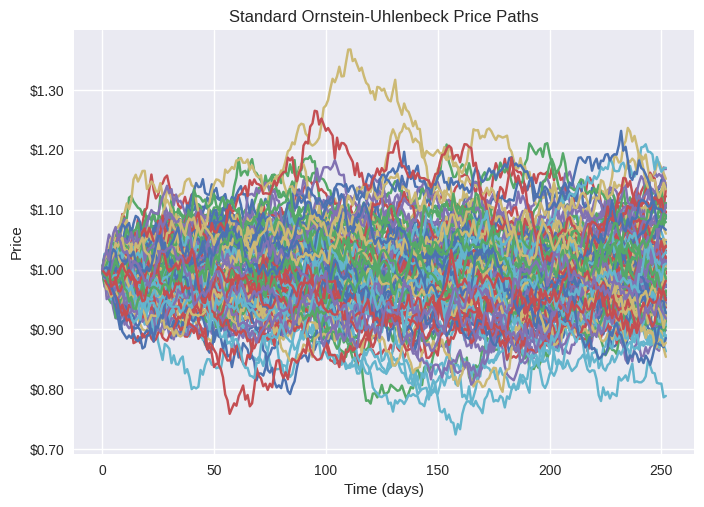

In [91]:
plt.plot(S)
plt.grid(True)
plt.xlabel("Time (days)")
plt.ylabel("Price")
plt.title("Standard Ornstein-Uhlenbeck Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.show()

# Adjusting Parameters for Seasonal Ornstein-Uhlenbeck Process

In [92]:
sigma = 0.4
theta = lambda i: S0 + 0.5 * np.cos(2 * np.pi / n * (i - n//2))

# Simulating Modified Seasonal Ornstein-Uhlenbeck Process

**Euler-Maruyama Discretization (For simulation):**

$$\theta_t = a + b \cos({\frac{2\pi (t-\frac{n}{2})}{n}})$$

$$S_{t+1,j} = S_{t,j} + \kappa(\theta_t - S_{t,j})\Delta t + \sigma \sqrt{\Delta t}\epsilon_{t,j}$$

where:

$t \in [0,n-1]$

$j \in [1,\text{num_paths}]$

$a$: Base mean level

$b$: Seasonal amplitude

In [93]:
for i in range(0,n):
  S[i+1] = S[i] + kappa * (theta(i) - S[i]) * dt + sigma * np.sqrt(dt) * epsilon[i]

# Plotting Modified Seasonal Ornstein-Uhlenbeck Process

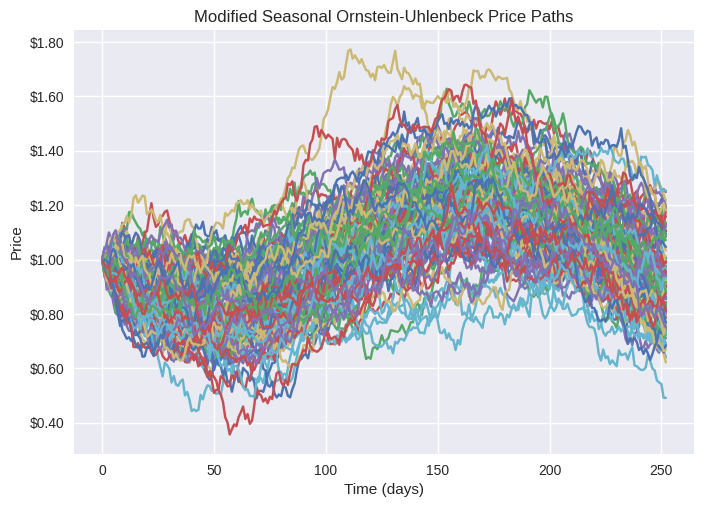

In [94]:
plt.plot(S)
plt.grid(True)
plt.xlabel("Time (days)")
plt.ylabel("Price")
plt.title("Modified Seasonal Ornstein-Uhlenbeck Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.show()